# Expected Goals (xG) Modeling

This notebook builds and evaluates machine learning models to predict goal probability (Expected Goals).

## Models:
1. Logistic Regression (baseline)
2. XGBoost (gradient boosting)
3. Model comparison and evaluation
4. Hyperparameter tuning


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


## Load Feature-Engineered Data


In [55]:
# Load data with all features
df_shots_clean = pd.read_parquet("../../data/processed/shots_with_all_features.parquet")

print(f"Data shape: {df_shots_clean.shape}")
print(f"Total shots: {len(df_shots_clean):,}")
print(f"Total goals: {df_shots_clean['is_goal'].sum():,}")
print(f"Goal rate: {df_shots_clean['is_goal'].mean():.2%}")


Data shape: (680581, 63)
Total shots: 680,581
Total goals: 36,940
Goal rate: 5.43%


## Data Preparation


In [56]:
# Exclude non-numeric and identifier columns
exclude_cols = [
    'eventId', 'timeInPeriod', 'timeRemaining', 'situationCode', 
    'typeDescKey', 'typeCode', 'sortOrder', 'assist1PlayerId', 
    'assist1PlayerTotal', 'assist2PlayerId', 'assist2PlayerTotal',
    'awaySOG', 'awayScore', 'blockingPlayerId', 'eventOwnerTeamId', 
    'goalieInNetId', 'homeSOG', 'homeScore', 'scoringPlayerId', 
    'scoringPlayerTotal', 'shootingPlayerId', 'xCoord', 'yCoord', 
    'zoneCode', 'period', 'periodType', 'shotType', 'homeTeamDefendingSide',
    'game_situation'  # Categorical column we've encoded
]

# Get feature columns
feature_cols = [col for col in df_shots_clean.columns
                if col not in exclude_cols and col != 'is_goal']

# Handle categorical features (distance_bin, angle_bin)
categorical_cols = [col for col in feature_cols 
                    if df_shots_clean[col].dtype == 'object' or 
                    df_shots_clean[col].dtype.name == 'category']

print(f"Number of features: {len(feature_cols)}")
print(f"Categorical features to encode: {categorical_cols}")

# Encode categorical features
X = df_shots_clean[feature_cols].copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

y = df_shots_clean['is_goal'].copy()

# Remove rows with any missing feature values (for models like LogisticRegression)
na_mask = X.isna().any(axis=1)
print(f"Rows with any NaNs in features: {na_mask.sum():,} ({na_mask.mean():.2%} of data)")

X = X[~na_mask].copy()
y = y[~na_mask].copy()

print(f"After dropping NaNs -> X shape: {X.shape}, y shape: {y.shape}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Goal rate: {y.mean():.2%}")


Number of features: 33
Categorical features to encode: ['distance_bin', 'angle_bin']


Rows with any NaNs in features: 1 (0.00% of data)
After dropping NaNs -> X shape: (680580, 33), y shape: (680580,)

Feature matrix shape: (680580, 33)
Target vector shape: (680580,)
Goal rate: 5.43%


## Train/Test Split


In [57]:
# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train):,} shots ({y_train.sum():,} goals, {y_train.mean():.2%} goal rate)")
print(f"Test set: {len(X_test):,} shots ({y_test.sum():,} goals, {y_test.mean():.2%} goal rate)")


Training set: 544,464 shots (29,552 goals, 5.43% goal rate)
Test set: 136,116 shots (7,388 goals, 5.43% goal rate)


## Model 1: Logistic Regression (Baseline)


In [58]:
print("="*60)
print("LOGISTIC REGRESSION - BASELINE MODEL")
print("="*60)

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
print("✓ Model trained!")

# Make predictions
y_train_pred_proba_lr = lr_model.predict_proba(X_train)[:, 1]
y_test_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
train_auc_lr = roc_auc_score(y_train, y_train_pred_proba_lr)
test_auc_lr = roc_auc_score(y_test, y_test_pred_proba_lr)

print(f"\nModel Performance:")
print(f"  Training AUC: {train_auc_lr:.4f}")
print(f"  Test AUC: {test_auc_lr:.4f}")

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr, target_names=['No Goal', 'Goal']))


LOGISTIC REGRESSION - BASELINE MODEL
✓ Model trained!

Model Performance:
  Training AUC: 0.7941
  Test AUC: 0.7976

Classification Report (Test Set):
              precision    recall  f1-score   support

     No Goal       0.95      1.00      0.97    128728
        Goal       0.32      0.00      0.00      7388

    accuracy                           0.95    136116
   macro avg       0.63      0.50      0.49    136116
weighted avg       0.91      0.95      0.92    136116



## Model 2: XGBoost


In [59]:
print("="*60)
print("XGBOOST MODEL")
print("="*60)

# Create and train XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✓ Model trained!")

# Make predictions
y_train_pred_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
train_auc_xgb = roc_auc_score(y_train, y_train_pred_proba_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_pred_proba_xgb)

print(f"\nModel Performance:")
print(f"  Training AUC: {train_auc_xgb:.4f}")
print(f"  Test AUC: {test_auc_xgb:.4f}")

# Compare with logistic regression
improvement = test_auc_xgb - test_auc_lr
print(f"\nComparison with Logistic Regression:")
print(f"  Logistic Regression Test AUC: {test_auc_lr:.4f}")
print(f"  XGBoost Test AUC: {test_auc_xgb:.4f}")
print(f"  Improvement: {improvement:+.4f} ({improvement*100:+.2f} percentage points)")


XGBOOST MODEL
✓ Model trained!

Model Performance:
  Training AUC: 0.8302
  Test AUC: 0.8218

Comparison with Logistic Regression:
  Logistic Regression Test AUC: 0.7976
  XGBoost Test AUC: 0.8218
  Improvement: +0.0242 (+2.42 percentage points)


## Model Comparison - ROC Curves


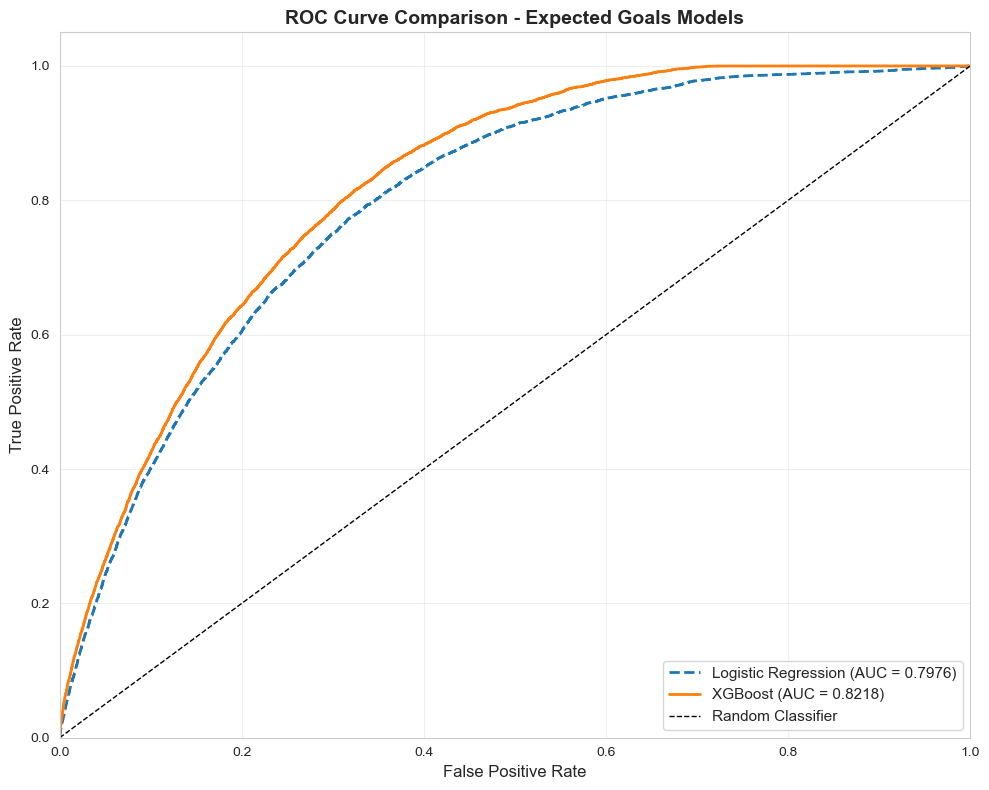

In [60]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_pred_proba_xgb)

# Plot comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {test_auc_lr:.4f})',
         linewidth=2, linestyle='--')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {test_auc_xgb:.4f})',
         linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Expected Goals Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Feature Importance (XGBoost)


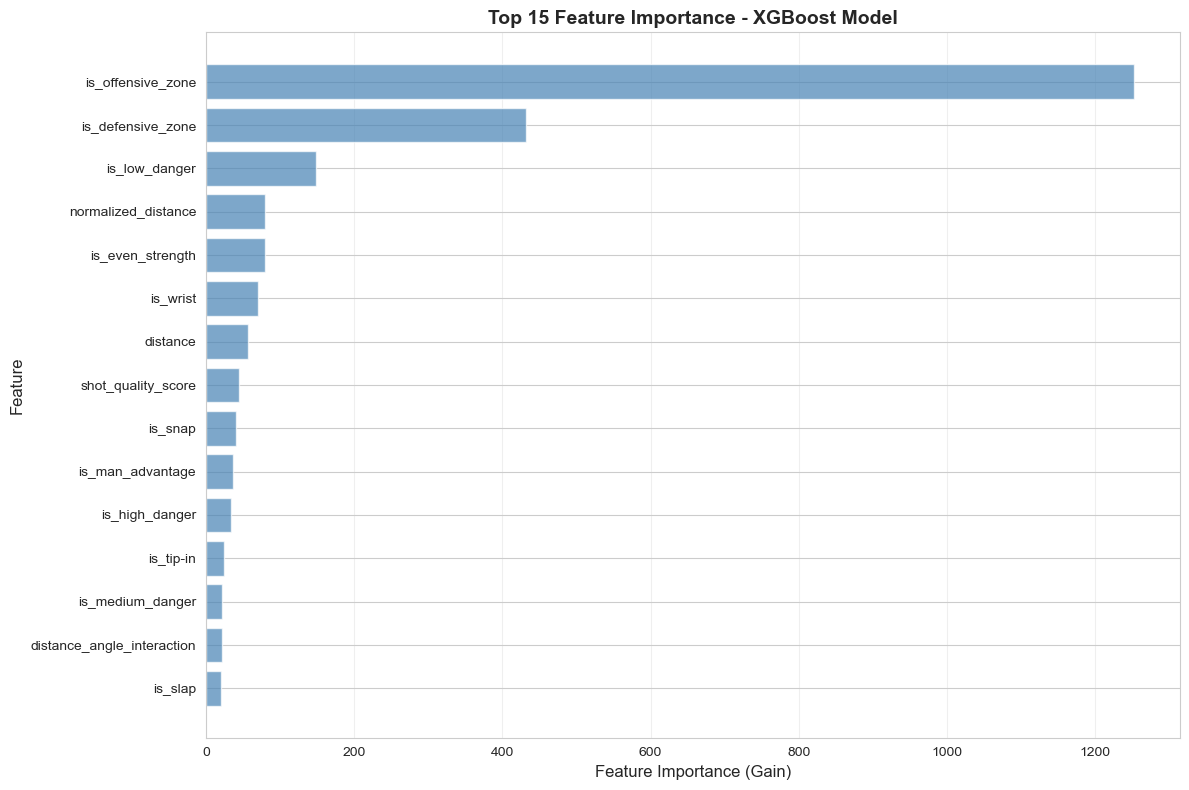


Top 15 Most Important Features:
                   feature  importance
         is_offensive_zone 1251.648438
         is_defensive_zone  432.099396
             is_low_danger  148.248306
       normalized_distance   79.963104
          is_even_strength   79.837036
                  is_wrist   69.979919
                  distance   57.363689
        shot_quality_score   44.239315
                   is_snap   40.557583
          is_man_advantage   35.887962
            is_high_danger   33.255280
                 is_tip-in   24.661835
          is_medium_danger   22.023727
distance_angle_interaction   21.450207
                   is_slap   20.207338


In [61]:
# Get feature importance (gain)
feature_importance_gain = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(feature_importance_gain.keys()),
    'importance': list(feature_importance_gain.values())
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importance - XGBoost Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))


## Hyperparameter Tuning (Optional - Takes Time)

This section performs grid search to find optimal hyperparameters. Uncomment to run.


In [62]:
# Uncomment to run hyperparameter tuning (takes several minutes)

print("="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)

# Define parameter grid (smaller grid for faster search)
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create base model
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# Grid search with cross-validation
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print("\n✓ Grid search complete!")
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")

# Use best model
xgb_best = grid_search.best_estimator_
y_test_pred_proba_best = xgb_best.predict_proba(X_test)[:, 1]
test_auc_best = roc_auc_score(y_test, y_test_pred_proba_best)

print(f"Test AUC with best model: {test_auc_best:.4f}")
print(f"Improvement over default: {test_auc_best - test_auc_xgb:+.4f}")

# print("Hyperparameter tuning code is commented out. Uncomment to run.")


HYPERPARAMETER TUNING - XGBOOST
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✓ Grid search complete!

Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 4
  n_estimators: 200
  subsample: 1.0

Best cross-validation AUC: 0.8183
Test AUC with best model: 0.8226
Improvement over default: +0.0008


## Final Model Summary


In [63]:
# Calculate detailed metrics for XGBoost
accuracy = accuracy_score(y_test, y_test_pred_xgb)
precision = precision_score(y_test, y_test_pred_xgb)
recall = recall_score(y_test, y_test_pred_xgb)
f1 = f1_score(y_test, y_test_pred_xgb)
ap = average_precision_score(y_test, y_test_pred_proba_xgb)

print("="*60)
print("FINAL MODEL SUMMARY - XGBOOST")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Test AUC': [test_auc_lr, test_auc_xgb]
})

print("\n" + comparison_df.to_string(index=False))

print(f"\nDetailed Metrics (XGBoost):")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score: {f1:.4f}")
print(f"  AUC-ROC: {test_auc_xgb:.4f}")
print(f"  Average Precision: {ap:.4f}")

print(f"\n✓ Model is ready for deployment!")


FINAL MODEL SUMMARY - XGBOOST

              Model  Test AUC
Logistic Regression  0.797565
            XGBoost  0.821759

Detailed Metrics (XGBoost):
  Accuracy: 0.9458 (94.58%)
  Precision: 0.5474 (54.74%)
  Recall: 0.0070 (0.70%)
  F1-Score: 0.0139
  AUC-ROC: 0.8218
  Average Precision: 0.2014

✓ Model is ready for deployment!


## Threshold Optimization for XGBoost

We optimize the decision threshold using the precision–recall curve to maximize the F1-score on the test set, then compare metrics at the default 0.50 threshold vs. the optimized threshold.

In [64]:
from sklearn.metrics import precision_recall_curve

# Use existing probability predictions from XGBoost: y_test_pred_proba_xgb
# 1) Metrics at default 0.50 threshold
y_pred_default = (y_test_pred_proba_xgb >= 0.50).astype(int)
precision_default = precision_score(y_test, y_pred_default, zero_division=0)
recall_default = recall_score(y_test, y_pred_default, zero_division=0)
f1_default = f1_score(y_test, y_pred_default, zero_division=0)

# 2) Find threshold that maximizes F1 using the precision–recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_test_pred_proba_xgb)

# precision_recall_curve returns an extra point at the end where threshold is undefined
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

# Metrics at optimized threshold
y_pred_opt = (y_test_pred_proba_xgb >= best_threshold).astype(int)
precision_opt = precision_score(y_test, y_pred_opt, zero_division=0)
recall_opt = recall_score(y_test, y_pred_opt, zero_division=0)
f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)

print("="*60)
print("XGBOOST THRESHOLD OPTIMIZATION")
print("="*60)

print("\nDefault threshold (0.50):")
print(f"  Precision: {precision_default:.4f} ({precision_default*100:.2f}%)")
print(f"  Recall:    {recall_default:.4f} ({recall_default*100:.2f}%)")
print(f"  F1-Score:  {f1_default:.4f}")

print(f"\nOptimized threshold ({best_threshold:.3f}):")
print(f"  Precision: {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"  Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"  F1-Score:  {f1_opt:.4f}")

print("\nNote: AUC-ROC and Average Precision do not depend on the threshold;\n      this step is purely about trading off precision vs recall.")

XGBOOST THRESHOLD OPTIMIZATION

Default threshold (0.50):
  Precision: 0.5474 (54.74%)
  Recall:    0.0070 (0.70%)
  F1-Score:  0.0139

Optimized threshold (0.133):
  Precision: 0.1942 (19.42%)
  Recall:    0.4368 (43.68%)
  F1-Score:  0.2688

Note: AUC-ROC and Average Precision do not depend on the threshold;
      this step is purely about trading off precision vs recall.


## Save Model

Save the trained model for future use.


In [65]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../../data/models", exist_ok=True)

# Save XGBoost model
model_path = "../../data/models/xgboost_xg_model.pkl"
joblib.dump(xgb_model, model_path)
print(f"Model saved to {model_path}")

# Save label encoders if needed
encoders_path = "../../data/models/label_encoders.pkl"
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to {encoders_path}")


Model saved to ../../data/models/xgboost_xg_model.pkl
Label encoders saved to ../../data/models/label_encoders.pkl
